In [1]:
# !pip install pandas numpy matplotlib seaborn holidays

## Data cleansing

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
def wrangle(path, col_1, col_2):
    # Import data
    df = pd.read_csv(path)

    # Convert to datetime
    df[col_1] = pd.to_datetime(df[col_1])

    # Rename the column to 'Date'
    df.rename(columns={col_1: 'Date'}, inplace=True)

    # Replace missing values
    df[col_2] = df[col_2].replace('.', pd.NA)

    # Convert to numeric, coercing errors to NaN
    df[col_2] = pd.to_numeric(df[col_2], errors='coerce')

    # Only select data between 2000-01-01 and 2024-12-31
    df = df[(df['Date'] >= '2000-01-01') & (df['Date'] <= '2024-12-31')]

    # Set index
    df = df.set_index('Date')

    return df

In [4]:
vix = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/vix.csv",
              "Date",
              "Close")
vix

,Close
Date,
2000-01-31,26.20
2000-02-29,25.59
2000-03-31,27.21
2000-04-30,28.86
2000-05-31,26.57
...,...
2024-08-31,15.00
2024-09-30,16.73
2024-10-31,23.16


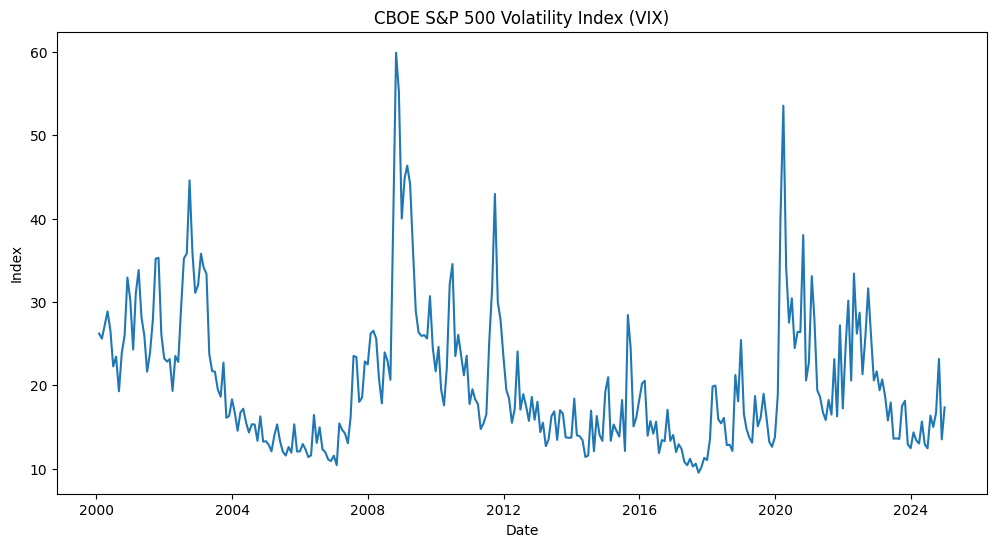

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(vix.index, vix['Close'])
plt.xlabel('Date')
plt.ylabel('Index')
plt.title("CBOE S&P 500 Volatility Index (VIX)");

In [6]:
JPY_USD = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/jpy_usd.csv",
                                    "Date",
                                    "Close")
JPY_USD

,Close
Date,
2000-01-31,107.36
2000-02-29,110.19
2000-03-31,102.75
2000-04-30,108.16
2000-05-31,107.61
...,...
2024-08-31,146.16
2024-09-30,143.62
2024-10-31,151.98


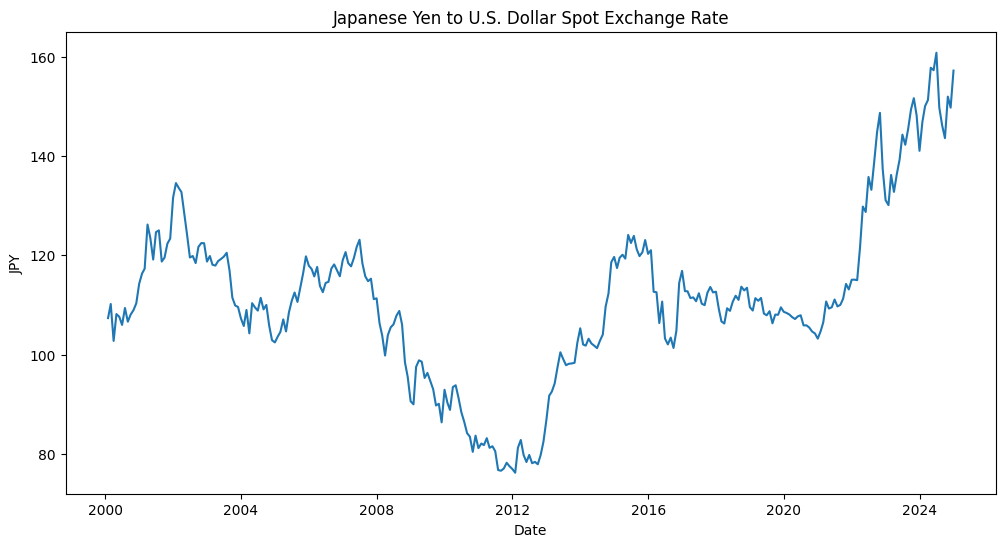

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(JPY_USD.index, JPY_USD['Close'])
plt.xlabel('Date')
plt.ylabel('JPY')
plt.title("Japanese Yen to U.S. Dollar Spot Exchange Rate");

In [8]:
jpy_1m_forward_rate = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/jpy_1m_forward_rate.csv",
                   "Date",
                   "Close")

jpy_1m_forward_rate

,Close
Date,
2000-01-31,106.370000
2000-02-29,109.310000
2000-03-31,102.070000
2000-04-30,107.170000
2000-05-31,106.830000
...,...
2023-11-30,144.138488
2023-12-31,137.199736
2024-01-31,142.895893


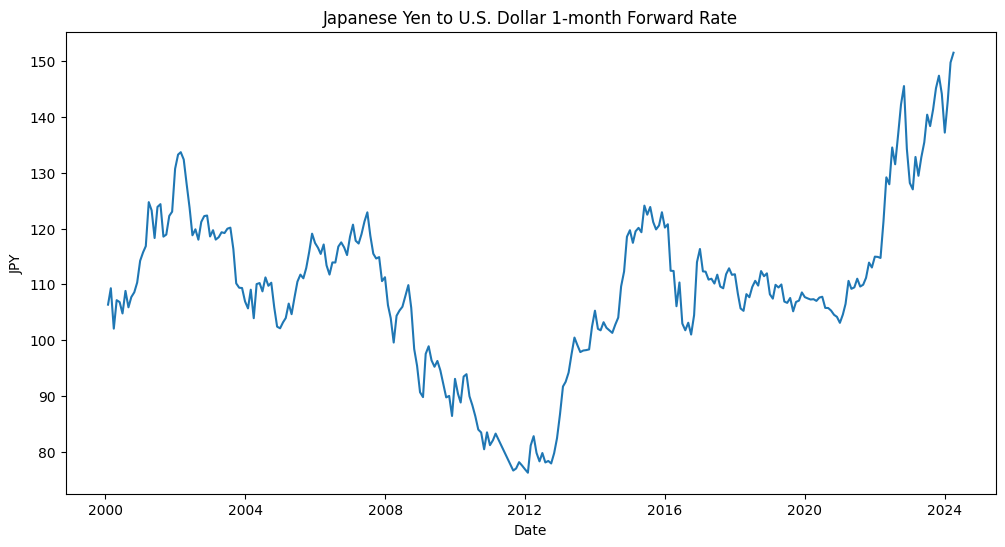

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(jpy_1m_forward_rate.index, jpy_1m_forward_rate['Close'])
plt.xlabel('Date')
plt.ylabel('JPY')
plt.title("Japanese Yen to U.S. Dollar 1-month Forward Rate");

#### Combining the data frames

In [10]:

# Renaming columns 
vix.rename(columns={"Close": "VIX"}, inplace=True)
JPY_USD.rename(columns={"Close": "spot_rate"}, inplace=True)
jpy_1m_forward_rate.rename(columns={"Close": "forward_rate_1month"}, inplace=True)

# Performing outer joins to keep all data
combined_df = pd.merge(vix, JPY_USD, on='Date', how='outer')
combined_df = pd.merge(combined_df, jpy_1m_forward_rate, on='Date', how='outer')

# Sorting by date for a cleaner view
combined_df.sort_index(inplace=True)

# Displaying the final dataframe and saving it
print(combined_df.head(10)) 
print(combined_df.tail(10)) 
combined_df.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/combined_data_full.csv", index=True)

              VIX  spot_rate  forward_rate_1month
Date                                             
2000-01-31  26.20     107.36               106.37
2000-02-29  25.59     110.19               109.31
2000-03-31  27.21     102.75               102.07
2000-04-30  28.86     108.16               107.17
2000-05-31  26.57     107.61               106.83
2000-06-30  22.26     105.98               104.79
2000-07-31  23.44     109.39               108.83
2000-08-31  19.28     106.63               105.89
2000-09-30  23.85     108.05               107.73
2000-10-31  25.99     108.96               108.59
              VIX  spot_rate  forward_rate_1month
Date                                             
2024-03-31  13.01     151.31              151.515
2024-04-30  15.65     157.80                  NaN
2024-05-31  12.92     157.31                  NaN
2024-06-30  12.44     160.83                  NaN
2024-07-31  16.36     149.78                  NaN
2024-08-31  15.00     146.16                  NaN


In [11]:
print(f"The number of non-NaN values: \n{combined_df.count()}")
print("\n")
print(f"The number of NaN values: \n{combined_df.isna().sum()}")

The number of non-NaN values: 
VIX                    300
spot_rate              300
forward_rate_1month    285
dtype: int64


The number of NaN values: 
VIX                     0
spot_rate               0
forward_rate_1month    15
dtype: int64


In [12]:
# # Interpolation to fill missing values
# combined_df = combined_df.interpolate(method='time').ffill()

# Drop rows with NaN values
combined_df.dropna(inplace=True)

# Count NaN values in each column
print(f"The number of non-NaN values: \n{combined_df.count()}")
print("\n")
print(f"The number of NaN values: \n{combined_df.isna().sum()}")

The number of non-NaN values: 
VIX                    285
spot_rate              285
forward_rate_1month    285
dtype: int64


The number of NaN values: 
VIX                    0
spot_rate              0
forward_rate_1month    0
dtype: int64


In [13]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 285 entries, 2000-01-31 to 2024-03-31
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   VIX                  285 non-null    float64
 1   spot_rate            285 non-null    float64
 2   forward_rate_1month  285 non-null    float64
dtypes: float64(3)
memory usage: 8.9 KB


In [14]:
combined_df.describe()

,VIX,spot_rate,forward_rate_1month
count,285.000000,285.000000,285.000000
mean,20.494491,110.217404,109.688118
std,8.450387,15.104993,14.586309
min,9.510000,76.190000,76.250000
25%,13.950000,103.420000,103.210000
50%,18.230000,110.190000,109.784064
75%,24.510000,118.440000,118.450000
max,59.890000,151.670000,151.515000


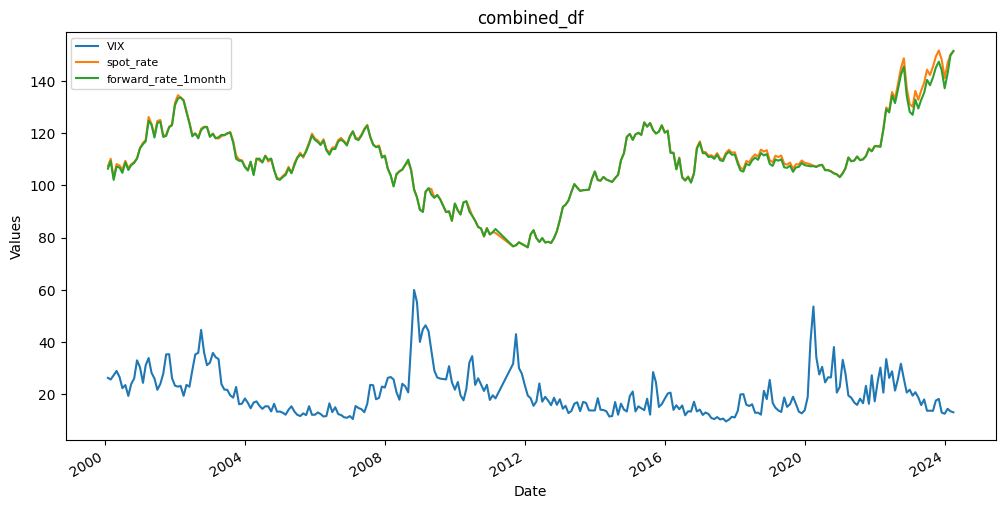

In [15]:
combined_df.plot(figsize=(12, 6), title="combined_df")
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend(loc='upper left', prop={'size': 8});

In [16]:
combined_df.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/combined_data_full.csv", index=True)

### Compute carry trade returns